# CARLA POMDP — a guided tour

`POMDPPlanners/environments/carla_pomdp/` adapts the [CARLA](https://carla.org/) driving simulator into a POMDP. It uses a **two-environment** design:

| Role | Class | Purpose |
|------|-------|---------|
| **World** | `CarlaPOMDP` | Forward-only ground truth. Drives a live CARLA server, ticks once per step, and runs **onboard perception in its observation model** so the emitted `agents` is a perceived, tracked object list. Cannot be queried from an arbitrary state. |
| **Model** | `KinematicCarlaModelPOMDP` (a `CarlaModelPOMDP`) | The generative model the planner searches inside. Pure Python — samples transitions/observations from *any* state, scores densities. No server needed. |
| **Belief** | `PerceivedAgentsBelief` | Plain particle filter over the ego; each step it **stamps** the observation's perceived `agents` block onto every particle. Does no perception itself. |

This tour shows the real inputs and outputs of each piece. Sections 1–3 run with no server; section 4 onward drives a live CARLA server on `localhost:2000`.

## 1. The schema

State and observation share one fixed layout, so world and model agree by construction.

- **State** `[ego(7) | agent_slots(K×5)]`, ego = `[x, y, yaw°, vx, vy, lat, heading_err]`, each agent slot = `[present, rel_x, rel_y, rel_yaw, rel_speed]` in the **ego frame** (rel_x forward, rel_y left).
- **Actions** are indices into discrete `(throttle, steer, brake)` presets.
- **Observation** is a dict: `gnss`, `agents` (same slots but out-of-range / occluded agents zeroed → the hidden variable), plus optional `camera` / `lidar`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from POMDPPlanners.core.belief import WeightedParticleBelief
from POMDPPlanners.environments.carla_pomdp.carla_pomdp import (
    EGO_STATE_WIDTH, AGENT_SLOT_WIDTH, DEFAULT_MAX_TRACKED_AGENTS,
    DEFAULT_ACTION_PRESETS, CarlaPOMDP,
)
from POMDPPlanners.environments.carla_pomdp.carla_belief import (
    PerceivedAgentsBelief,
)
from POMDPPlanners.environments.carla_pomdp.carla_perception import (
    CarlaPerceptionPipeline,
)
from POMDPPlanners.environments.carla_pomdp.carla_generative_models import (
    KinematicCarlaModelPOMDP,
)

K = DEFAULT_MAX_TRACKED_AGENTS
STATE_WIDTH = EGO_STATE_WIDTH + K * AGENT_SLOT_WIDTH
print(f'ego width      : {EGO_STATE_WIDTH}')
print(f'agent slot     : {AGENT_SLOT_WIDTH}  x {K} tracked agents')
print(f'full state dim : {STATE_WIDTH}')
print('\naction presets (throttle, steer, brake):')
for i, preset in enumerate(DEFAULT_ACTION_PRESETS):
    print(f'  {i}: {preset}')

ego width      : 7
agent slot     : 5  x 5 tracked agents
full state dim : 32

action presets (throttle, steer, brake):
  0: (0.5, 0.0, 0.0)
  1: (0.3, -0.5, 0.0)
  2: (0.3, 0.5, 0.0)
  3: (0.0, 0.0, 1.0)


## 2. The planner-side model

`KinematicCarlaModelPOMDP` is fully runnable without a server. It propagates the ego with a kinematic bicycle model and carries agents forward by the closing range. Build a state with one car 4 m ahead and drive it.

In [2]:
model = KinematicCarlaModelPOMDP(discount_factor=0.95, dt=0.05)
print('actions:', model.get_actions())

# ego at origin, stationary; one agent 4 m ahead in-lane, present flag = 1
state = np.zeros(STATE_WIDTH)
state[EGO_STATE_WIDTH:EGO_STATE_WIDTH + AGENT_SLOT_WIDTH] = [1.0, 4.0, 0.0, 0.0, 0.0]
print('ego before:', state[:EGO_STATE_WIDTH])

2026-07-05 18:52:18,515 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/environment/environment.py:186 - Initializing KinematicCarlaModelPOMDP environment with discount factor 0.95


actions: [0, 1, 2, 3]
ego before: [0. 0. 0. 0. 0. 0. 0.]


In [3]:
# action 0 = (0.5, 0.0, 0.0) cruise straight -> throttle produces forward motion
next_state = model.sample_next_state(state, action=0)
print('ego after cruise:', np.round(next_state[:EGO_STATE_WIDTH], 3))
print('vx grew from 0 ->', round(float(next_state[3]), 3), 'm/s')

print('\nreward(cruise) :', round(model.reward(state, 0, next_state), 3))
print('is_terminal    :', model.is_terminal(state),
      '(agent 4 m ahead is inside the 5 m collision box)')

ego after cruise: [0.004 0.    0.    0.075 0.    0.    0.   ]
vx grew from 0 -> 0.075 m/s

reward(cruise) : -100.025
is_terminal    : True (agent 4 m ahead is inside the 5 m collision box)


In [4]:
# The observation model is factored + noisy. Sample what the sensors would report
# for this state, and score that observation's likelihood under the model.
np.random.seed(0)
obs = model.sample_observation(next_state, action=0)
print('observation keys :', sorted(obs))
print('gnss             :', np.round(obs['gnss'], 4))
print('agents (slots)   :')
print(np.round(np.asarray(obs['agents']).reshape(K, AGENT_SLOT_WIDTH), 3))

logp = model.observation_log_probability(next_state, 0, obs)
print('\nlog p(obs | state):', np.round(logp, 2))

observation keys : ['agents', 'gnss']
gnss             : [ 0.0038 -0.    ]
agents (slots)   :
[[1.    4.878 0.2   0.489 1.12 ]
 [0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.   ]]

log p(obs | state): [18.9]


## 3. The belief

Perception lives in the **world's observation model** (§4): `CarlaPOMDP` runs a `CarlaPerceptionPipeline` and emits a *perceived* `agents` block (vehicles clustered/tracked from the lidar, hazards and a camera-inferred light folded in). The belief does no perception — it just **stamps** the observation's `agents` block onto every particle, because a plain particle filter can never *acquire* a car that appears mid-drive. Below we feed a perceived `agents` observation directly.

In [5]:
N_DEMO = 6
particles = [np.zeros(EGO_STATE_WIDTH + AGENT_SLOT_WIDTH) for _ in range(N_DEMO)]
belief = PerceivedAgentsBelief(
    particles=particles,
    log_weights=np.log(np.ones(N_DEMO) / N_DEMO),
    max_tracked_agents=1,
)
before = np.asarray(belief.particles)[0]

# A perceived observation: the world's observation model already turned raw sensors into this.
observation = {'gnss': np.zeros(2), 'agents': np.array([1.0, 8.0, 0.0, 0.0, 5.0])}
base = WeightedParticleBelief(particles=particles, log_weights=belief.log_weights)
refreshed = belief.reinvigorate('noop', observation, model, base)
after = np.asarray(refreshed.particles)[0]

print('particle agent slot before:', before[EGO_STATE_WIDTH:])
print('particle agent slot after :', np.round(after[EGO_STATE_WIDTH:], 3),
      '<- car stamped (present=1, ~8 m ahead)')

particle agent slot before: [0. 0. 0. 0. 0.]
particle agent slot after : [ 1.     8.285 -0.045 -0.031  5.123] <- car injected (present=1, ~8 m ahead)


## 4. The live CARLA world

Now the real thing. `CarlaPOMDP` connects to the running server, loads a town, spawns the ego + autopilot traffic, and reads genuine sensor payloads. Resetting takes a few seconds.

> Requires a CARLA `0.9.15` server on `localhost:2000`. If none is up, this section raises — the model/belief sections above stand alone.

In [6]:
world = CarlaPOMDP(
    discount_factor=0.95,
    town='Town02',        # compact, dense map
    num_vehicles=20,      # surrounding autopilot traffic
    num_walkers=0,
    randomize_spawn=False,
    include_camera=True,
    include_lidar=True,
    fixed_delta_seconds=0.05,
    # Onboard perception in the observation model: emit a perceived, tracked `agents` block
    # (vehicles from the lidar, a camera-inferred red/amber light folded in as a hazard).
    perception_pipeline=CarlaPerceptionPipeline(
        max_tracked_agents=K, sensor_fusion=True, stop_for_traffic_lights=True, dt=0.05,
    ),
    seed=0,
    timeout=20.0,
)

true_state = world.initial_state_dist().sample(1)[0]      # resets + ticks once
obs0 = world.initial_observation_dist().sample(1)[0]
print('true state dim :', np.asarray(true_state).shape)
print('observation    :', sorted(obs0))

2026-07-05 18:52:18,529 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/environment/environment.py:186 - Initializing CarlaPOMDP-Town02 environment with discount factor 0.95


true state dim : (32,)
observation    : ['agents', 'camera', 'gnss', 'lidar']


In [7]:
# Ground-truth ego kinematics and the nearest tracked agents (world frame -> ego frame)
print('ego [x, y, yaw, vx, vy, lat, heading_err]:')
print(np.round(np.asarray(true_state)[:EGO_STATE_WIDTH], 3))
print('\ntrue nearest-agent slots [present, rel_x, rel_y, rel_yaw, rel_speed]:')
print(np.round(np.asarray(true_state)[EGO_STATE_WIDTH:].reshape(K, AGENT_SLOT_WIDTH), 2))

ego [x, y, yaw, vx, vy, lat, heading_err]:
[-7.5300e+00  1.4219e+02  9.0000e+01  0.0000e+00  0.0000e+00  1.1500e-01
 -2.0000e-03]

true nearest-agent slots [present, rel_x, rel_y, rel_yaw, rel_speed]:
[[  1.     0.    -3.85  -3.14   0.  ]
 [  1.    16.79   0.     0.     0.  ]
 [  1.    16.79  -3.85  -3.14   0.  ]
 [  1.   -20.98  -0.     0.     0.  ]
 [  1.   -20.98  -3.85  -3.14   0.  ]]


In [8]:
# The observation: GNSS + the *detected* agents (out-of-range / occluded ones zeroed)
print('gnss [lat, lon, alt] :', np.round(obs0['gnss'], 6))
print('\ndetected agent slots (the hidden-variable view the belief must reason about):')
print(np.round(np.asarray(obs0['agents']).reshape(K, AGENT_SLOT_WIDTH), 2))

gnss [lat, lon, alt] : [ 1.278e-03 -6.800e-05  4.853e-01]

detected agent slots (the hidden-variable view the belief must reason about):
[[  1.     0.    -3.85  -3.14   0.  ]
 [  1.    16.79   0.     0.     0.  ]
 [  1.    16.79  -3.85  -3.14   0.  ]
 [  1.   -20.98  -0.     0.     0.  ]
 [  1.   -20.98  -3.85  -3.14   0.  ]]


camera: (128, 128, 3) uint8
lidar : (2638, 4) float32


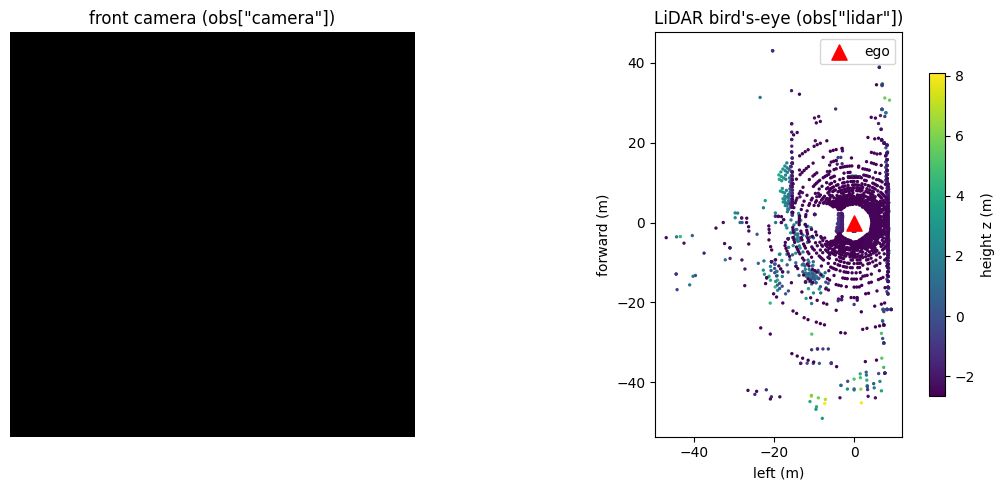

In [9]:
%matplotlib inline
# Real camera + LiDAR payloads
camera = obs0['camera']          # (H, W, 3) uint8, front-facing RGB
lidar = obs0['lidar']            # (N, 4) float32 [x, y, z, intensity], sensor frame
print('camera:', camera.shape, camera.dtype)
print('lidar :', lidar.shape, lidar.dtype)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 5))
ax0.imshow(camera)
ax0.set_title('front camera (obs["camera"])')
ax0.axis('off')

sc = ax1.scatter(lidar[:, 1], lidar[:, 0], c=lidar[:, 2], s=2, cmap='viridis')
ax1.scatter([0], [0], c='red', marker='^', s=120, label='ego')
ax1.set_title('LiDAR bird\'s-eye (obs["lidar"])')
ax1.set_xlabel('left (m)')
ax1.set_ylabel('forward (m)')
ax1.set_aspect('equal')
ax1.legend(loc='upper right')
fig.colorbar(sc, ax=ax1, label='height z (m)', shrink=0.8)
plt.tight_layout()
plt.show()

In [10]:
# Step the live world forward one tick with action 0 (cruise). The world is
# forward-only: it can only be stepped from its current live state.
next_true = world.sample_next_state(true_state, action=0)
step_reward = world.reward(true_state, action=0)
print('ego after one tick:', np.round(np.asarray(next_true)[:EGO_STATE_WIDTH], 3))
print('reward            :', round(step_reward, 3))
print('terminal (crash)? :', world.is_terminal(next_true))

ego after one tick: [-7.5300e+00  1.4219e+02  9.0000e+01  0.0000e+00  0.0000e+00  1.1500e-01
 -2.0000e-03]
reward            : -0.1
terminal (crash)? : False


## 5. The full POMDP cycle

World + model + belief together: step the real world, feed its real observation into a belief update that runs on the *model*, and watch the particle cloud track the traffic. This is exactly what the episode loop does under a planner.

In [11]:
# Seed a belief from the world's first observation: ego near origin, agent slots taken
# from what the world's perception actually detected at step 0.
N_PARTICLES = 40
log_w = np.log(np.ones(N_PARTICLES) / N_PARTICLES)
observed = np.asarray(obs0['agents'], dtype=float)
seed = []
for _ in range(N_PARTICLES):
    p = np.zeros(STATE_WIDTH)
    p[:EGO_STATE_WIDTH] = np.random.normal(0.0, 0.1, size=EGO_STATE_WIDTH)
    p[EGO_STATE_WIDTH:] = observed
    seed.append(p)
# The belief does no perception; it stamps the world's perceived `agents` block each update.
belief = PerceivedAgentsBelief(
    particles=seed, log_weights=log_w,
    max_tracked_agents=K, resampling=True,
)

def present_agents(b):
    """Mean number of present agent slots across the belief's particles."""
    rows = np.asarray(b.particles)[:, EGO_STATE_WIDTH:]
    slots = rows.reshape(len(b.particles), K, AGENT_SLOT_WIDTH)
    return float(slots[:, :, 0].sum(axis=1).mean())

print(f'{"step":>4} | {"action":>6} | {"reward":>7} | belief mean present agents')
s = np.asarray(true_state)
for t in range(6):
    a = 0  # cruise straight; a planner would choose this via POMCPOW
    ns = world.sample_next_state(s, a)          # advance the real world
    r = world.reward(s, a)
    obs = world.sample_observation(ns, a)       # real sensor reading
    belief = belief.update(a, obs, model)       # belief update on the MODEL
    print(f'{t:>4} | {a:>6} | {r:>7.3f} | {present_agents(belief):>5.2f}')
    s = ns
    if world.is_terminal(ns):
        print('collision -> episode terminal')
        break

step | action |  reward | belief mean present agents


   0 |      0 |  -0.100 |  5.00
   1 |      0 |  -0.100 |  5.00
   2 |      0 |  -0.100 |  5.00
   3 |      0 |  -0.100 |  5.00
   4 |      0 |  -0.100 |  5.00
   5 |      0 |  -0.100 |  5.00


## Where to go next

- **Run a real planner**: `carla_pomcpow_example.py` drives this world with POMCPOW and records CARLA's chase-camera as an MP4.
- **Swap the dynamics**: subclass `CarlaModelPOMDP`, or pass a trained `DreamerCarlaModelPOMDP` checkpoint so the planner searches inside a learned world model instead of the kinematic one.
- **Tune perception**: `perception_range`, `occlusion_radius`, `max_tracked_agents` control how much of the traffic is hidden — i.e. how hard the partial observability is.